# Week 3 Assignment - Country Clustering using K-Means and DBSCAN

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [2]:

df = pd.read_csv('Country-data.csv')

print(df.shape)
display(df.head())


(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:

# Data Cleaning
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.fillna(df.median(numeric_only=True))

print(df.isnull().sum())


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [4]:

X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


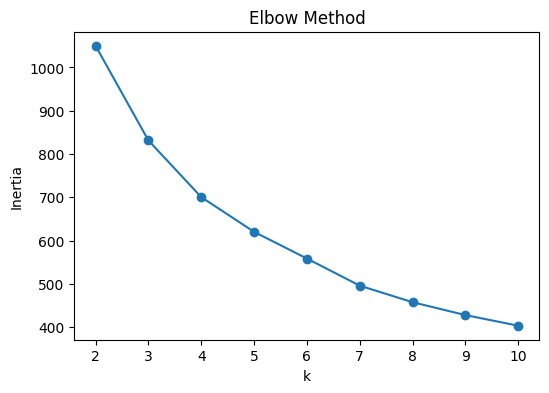

In [5]:

inertia = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()


In [6]:

best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, kmeans_labels)
print('Silhouette Score:', sil_score)


Silhouette Score: 0.28329575683463126


In [7]:

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

print(pd.Series(dbscan_labels).value_counts())


 0    137
-1     30
Name: count, dtype: int64


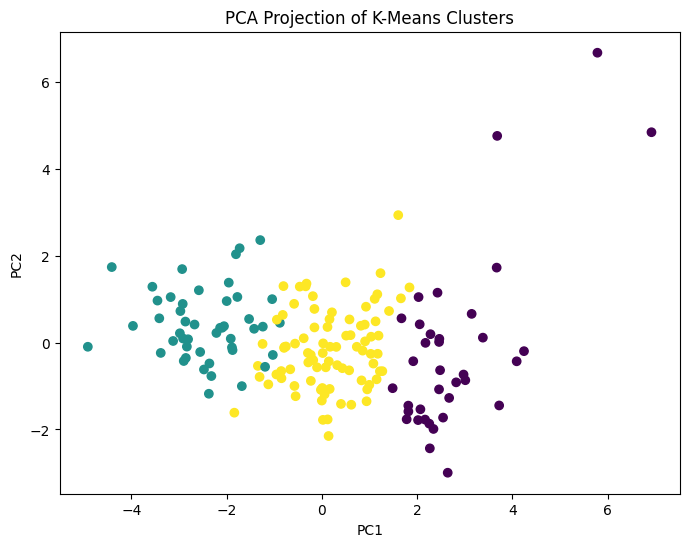

In [8]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.title('PCA Projection of K-Means Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()



## Section 14 Observations

1. One cluster contains countries with high child mortality and low life expectancy, indicating low-development regions.

2. Another cluster contains countries with high income, GDP per capita, and life expectancy, representing top-tier economic zones.

3. Developing countries are concentrated in a middle cluster with moderate socio-economic indicators.

4. PCA visualization shows reasonably separated country groups, supporting the K-Means segmentation.

5. DBSCAN identifies dense groups and may classify some countries as outliers/noise.
